# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [141]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [142]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [143]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [144]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [145]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [146]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [147]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [148]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [149]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [150]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [151]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En users hay dos columnas con valores faltantes: **city** y **churn_date**.
- Por otra parte, en usage hay tres columnas con valores faltantes: **date**, **duration** y **length**.  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- En **users** la columna **churn_date** debería eliminarse o ignorarse, pues casi el 90% de sus datos son nulos o estan faltantes. Asimismo, **city** debería imputarse ya que, el 11% de los datos estan faltantes.
- En contraste, el caso de **usage** es más critico porque hay dos columnas con el % de valores faltantes entre el 45 y 55%. En este caso lo recomendable es investigar a fondo a que se deben estos valores faltantes para asi tomar una decisión. Por su parte, los ausentes de la columna **date** se podrían ingnorar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.

- El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [152]:
# explorar columnas numéricas de users
num_cols_users = ['user_id','age']
print(users[num_cols_users].describe())
print("=== Análisis del sentinel -999 en age ===")
print(f"Total de registros: {len(users)}")
print(f"Valores -999: {(users['age'] == -999).sum()}")
print(f"Porcentaje: {(users['age'] == -999).mean() * 100:.2f}%")

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000
=== Análisis del sentinel -999 en age ===
Total de registros: 4000
Valores -999: 55
Porcentaje: 1.38%


- La columna `user_id` tiene su media y mediana muy similares, lo que significa que los valores se distribuyen de forma simetrica. No parece haber sentinels.
- La columna `age` por el contrario, la media y la mediana varían y se encuentra que el valor minimo es de **-999** y representa el 1.38% de los valores totales.

In [153]:
# explorar columnas numéricas de usage
num_cols_usage=['id','user_id']
usage[num_cols_usage].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- La columnas `id` tiene 40,000 registros secuenciales que van de 1 a 40,000 con distribución uniforme. Tiene una desviación estándar alta (11,547.15), indicando que los datos están bien dispersos a lo largo del rango completo.
- La columna `user_id` tiene 40,000 registros concentrados entre 10,000 y 13,999, con desviación estándar mucho menor (1,157.28). Esto sugiere aproximadamente 4,000 usuarios únicos en el dataset.

In [154]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())


for col in columnas_user:
    print(col)
    print('Frecuencia absoluta')
    print(users[col].value_counts(dropna=False))
    print('Frecuencia relativa')
    print(users[col].value_counts(normalize=True,dropna=False))

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595
city
Frecuencia absoluta
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Frecuencia relativa
Bogotá      0.20200
CDMX        0.18250
Medellín    0.15400
NaN         0.11725
GDL         0.11250
Cali        0.10600
MTY         0.10175
?           0.02400
Name: city, dtype: float64
plan
Frecuencia absoluta
Basico     2595
Premium    1405
Name: plan, dtype: int64
Frecuencia relativa
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


- La columna `city` contiene 7 valores unicos, donde Bogotá y CDMX representan más 40% del mercado. Asimismo, se encontró valores `?`, aproximadamente un 3% del total. 
- La columna `plan` solo tiene 2 valores unicos (basico y premium), el plan basico representa casi dos terceras partes de los usuarios.

In [155]:
# explorar columna categórica de usage
print(usage['type'].describe())
print('Frecuencia absoluta')
print(usage['type'].value_counts())
print('Frecuencia relativa')
print(usage['type'].value_counts(normalize=True))

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object
Frecuencia absoluta
text    22092
call    17908
Name: type, dtype: int64
Frecuencia relativa
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` tiene dos valores unicos. *text* aparece 22092 veces, representando el 55% y *call* 17908 veces, reprentando el 45%, mostrando una distribución relativamente balanceada.


---
✍️ **Comentario**: 

### Problemas identificados en los datos:

**Columnas numéricas:**
- En la columna `age`: Encontré valores de -999 que son sentinels para datos faltantes.

**Columnas categóricas:**
- En la columna `city`: Hay valores "?" que representan ciudades desconocidas y que dos ciudades concentran casi la mitad de los usuarios. 
- En la columna `plan`: La distribución muestra que el 60% usa plan básico.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- La columna `age` contiene valores sentinels que requieren atención. La columna `city` presenta caracteres '?' para representar ciudades no identificadas o faltantes.
- ¿Qué acción tomarías?
- Para los valores de `age` se pueden remplazar por Nans porque representan menos del 5% de los valores totales. En la columna `city` se remplazaria el valor *?* por *NA* porque tambien representan menos del 5%.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [156]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors='coerce')
print(users['reg_date'].head())

0   2022-01-01 00:00:00.000000000
1   2022-01-01 06:34:17.914478619
2   2022-01-01 13:08:35.828957239
3   2022-01-01 19:42:53.743435858
4   2022-01-02 02:17:11.657914478
Name: reg_date, dtype: datetime64[ns]


In [157]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce')
usage['date'].head()

0   2024-01-01 00:00:00.000000000
1   2024-01-01 00:06:30.969774244
2   2024-01-01 00:13:01.939548488
3   2024-01-01 00:19:32.909322733
4   2024-01-01 00:26:03.879096977
Name: date, dtype: datetime64[ns]

In [158]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())
print(f"Fecha mínima: {users['reg_date'].min()}")
print(f"Fecha máxima: {users['reg_date'].max()}")

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64
Fecha mínima: 2022-01-01 00:00:00
Fecha máxima: 2026-05-10 00:00:00


En `reg_date`, hay datos desde inicios del 2022 hasta mayo del 2026 

In [159]:
# Revisar los años presentes en `date` de usage
print(f"Fecha mínima: {usage['date'].min()}")
print(f"Fecha máxima: {usage['date'].max()}")
print(usage['date'].dt.year.value_counts().sort_index())

Fecha mínima: 2024-01-01 00:00:00
Fecha máxima: 2024-06-30 00:00:00
2024.0    39950
Name: date, dtype: int64


En `date`, por su parte, solo tiene fechas del primer semestre del año 2024. En consecuencia, nuestro analisis se basara unicamente en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Sí, hay datos del año 2026 de meses que aun no han transcurrido.
- ¿Qué harías con ellas?
- Teniendo en cuenta que la tabla de usage solo tiene registros del primer semestre del año 2024 solo se deberían tener en cuenta los datos del mismo periodo de tiempo de la tabla users.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [160]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [161]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
print(users['city'].describe())
print(users['city'].value_counts(dropna=False))


count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [162]:
# Marcar fechas futuras como NA para reg_date
fecha_limite = pd.Timestamp('2024-06-30')
users.loc[users['reg_date'] > fecha_limite, 'reg_date'] = pd.NaT

# Verificar cambios
print("Años después de la limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())
print(f"Registros con fechas NA: {users['reg_date'].isna().sum()}")


Años después de la limpieza:
2022.0    1314
2023.0    1316
2024.0     659
Name: reg_date, dtype: int64
Registros con fechas NA: 711


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [163]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [164]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

- En la columna  `duration `, el 99.9% de los valores nulos corresponden a registros de tipo 'text', ya que es imposible calcular duración en mensajes de texto. Es importante mantener estos datos como nulos en lugar de imputar valores falsos, pues esto distorsionaría los análisis posteriores. Este patrón de ausencia indica que los datos son MAR (Missing At Random), es decir, la falta de valores no es aleatoria sino condicionada al tipo de comunicación.
- En la columna  `length `, ocurre el patrón inverso: el 99.9% de los valores nulos corresponden a registros de tipo 'call', ya que es imposible medir la longitud de una llamada, mientras que sí es posible cuantificar la longitud de un mensaje de texto. Similarmente, estos datos también exhiben un patrón MAR, donde la ausencia de valores está condicionada al tipo de comunicación. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [165]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # Total de mensajes
    'is_call': 'sum',      # Total de llamadas  
    'duration': 'sum'      # Total de minutos
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [166]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes','is_call':'cant_llamadas','duration':'cant_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [167]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


In [168]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               3999 non-null   int64         
 1   first_name            3999 non-null   object        
 2   last_name             3999 non-null   object        
 3   age                   3999 non-null   float64       
 4   city                  3434 non-null   object        
 5   reg_date              3288 non-null   datetime64[ns]
 6   plan                  3999 non-null   object        
 7   churn_date            466 non-null    object        
 8   cant_mensajes         3999 non-null   int64         
 9   cant_llamadas         3999 non-null   int64         
 10  cant_minutos_llamada  3999 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(5)
memory usage: 374.9+ KB


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [169]:
# Resumen estadístico de las columnas numéricas
num_cols=['cant_llamadas','cant_mensajes','cant_minutos_llamada']
user_profile[num_cols].describe()

,cant_llamadas,cant_mensajes,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,4.478120,5.524381,23.317054
std,2.144238,2.358416,18.168095
min,0.000000,0.000000,0.000000
25%,3.000000,4.000000,11.120000
50%,4.000000,5.000000,19.780000
75%,6.000000,7.000000,31.415000
max,15.000000,17.000000,155.690000


In [170]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

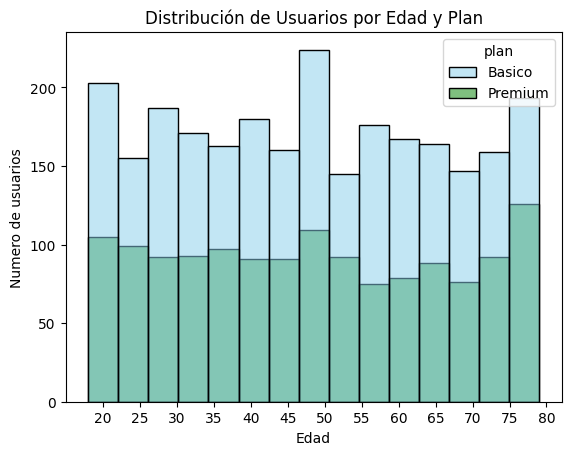

In [171]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', bins=15, hue='plan', palette=['skyblue','green'])
plt.xlabel('Edad')
plt.ylabel('Numero de usuarios')
plt.title('Distribución de Usuarios por Edad y Plan')
plt.xticks(range(20, 85, 5))
plt.show()


💡Insights: 
- Se evidencia que la distribución es simetrica y no posee sesgo, teniendo un pico en los usuarios de 50 años.
- Los usuarios Premium aumentan significativamente a partir de los 70-80 años.
- Los usuarios jovenes (entre 20 y 50 prefieren el plan básico.

In [172]:
user_profile['cant_mensajes'].describe()

count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64

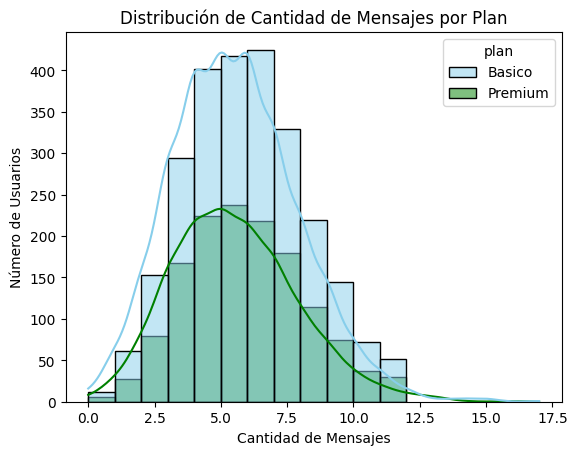

In [173]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', bins=12, hue='plan', binrange=(0,12), palette=['skyblue','green'],  kde=True)
    
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Número de Usuarios')
plt.show()


💡Insights: 

- **Los usuarios Premium envían ligeramente más mensajes.** La curva de Premium está desplazada hacia la derecha frente a Básico, lo que indica que en promedio los usuarios premium tienen mayor actividad. El plan premium sí está asociado a mayor engagement.
- **La mayoría de usuarios (ambos planes) se concentra entre 4 y 8 mensajes**. Ambas distribuciones tienen su mayor densidad en ese rango. Ese es el comportamiento normal del usuario promedio.
- **Los usuarios Básicos muestran mayor dispersión.** La distribución de Básico es más ancha y con cola más larga (hasta ~16-17 mensajes), mientras Premium es más concentrado. En Básico hay más variabilidad; Premium es un grupo más consistente en comportamiento.

In [174]:
user_profile['cant_llamadas'].describe()

count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64

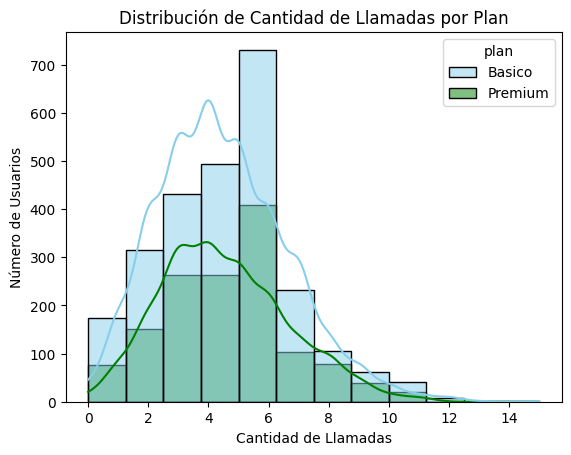

In [175]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=12, hue='plan', palette=['skyblue','green'],  kde=True)
    
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Número de Usuarios')
plt.show()

💡Insights: 
- **La distribución esta sesgada a la derecha**. La mayoría de usuarios hace pocas llamadas (2–6), pero hay una cola hacia valores altos (10+).Existe un grupo pequeño de usuarios intensivos que concentran mucho uso.
- **El comportamiento entre planes es bastante similar**. Las curvas de Básico y Premium se superponen bastante en el rango principal. A diferencia de los mensajes, el plan no cambia tanto el patrón de llamadas.
- **Mayor variabilidad en usuarios Básicos**. El plan Básico muestra una cola más larga y más dispersión hacia valores altos. Los usuarios básicos son menos predecibles; algunos usan muy poco y otros mucho.


In [176]:
user_profile['cant_minutos_llamada'].describe()

count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64

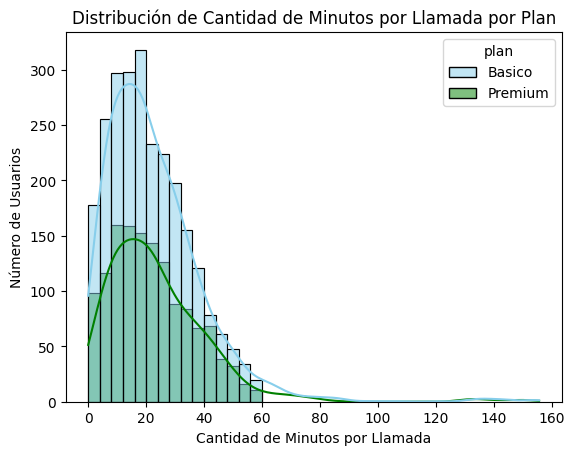

In [177]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=15, binrange=(0,60), hue='plan',palette=['skyblue','green'], edgecolor='black',  kde=True)

plt.title('Distribución de Cantidad de Minutos por Llamada por Plan')
plt.xlabel('Cantidad de Minutos por Llamada')
plt.ylabel('Número de Usuarios')
plt.show()

💡Insights: 
- **La distribución esta sesgada a la derecha**. La mayoria de usuarios hace llamadas entre 0 a 40 minutos.Existe un grupo pequeño de usuarios intensivos que concentran mucho uso.
- **Los usuarios del plan Premium tienden a realizar llamadas más largas que los del plan Básico**. Mientras el Básico se concentra en 15–20 minutos, el Premium lo hace en 20–25. Esto sugiere un mayor uso promedio, probablemente por mejores condiciones en su plan.
  

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

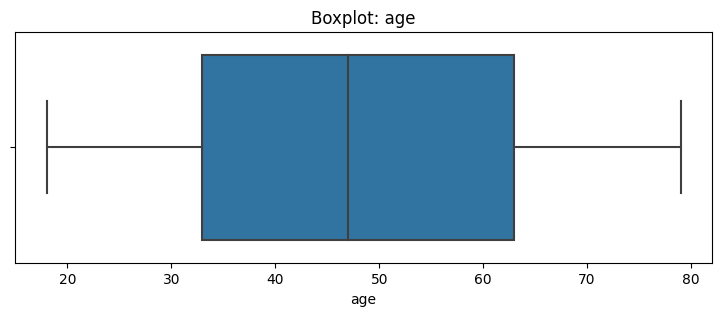

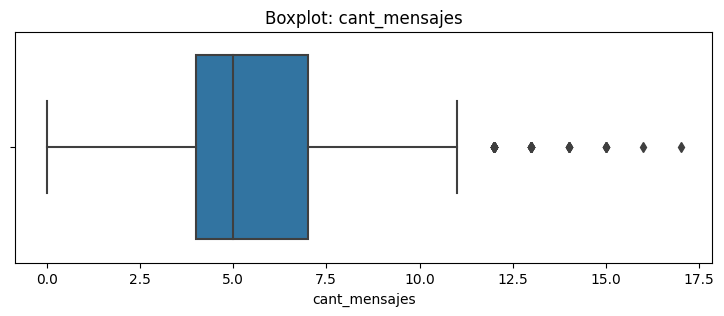

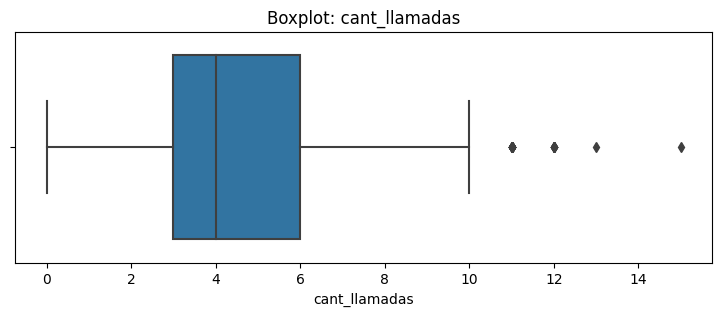

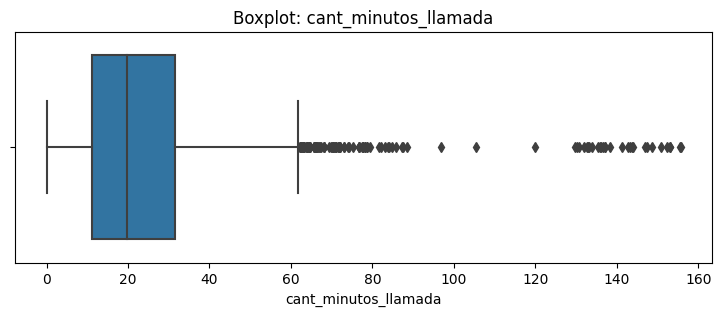

In [178]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(9,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers, distriución my consistente, no hay presente usuarios con edades *ficticias* (0 o 120 años).
- cant_mensajes: sí presenta outliers. Representan una pequeña cantidad de usuarios que envian más mensajes que el promedio.
- cant_llamadas: sí hay outliers. Representan una pequeña porción de usuarios que hacen más llamadas que los usuarios promedio.
- cant_minutos_llamada: sí hay outliers, es donde más se evidencian outliers. Representan las llamadas que estan muy por encima del promedio de minutos de las llamadas realizadas por los usuarios.

In [179]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
for col in columnas_limites:
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR=Q3-Q1
    
    print(col,'IQR',IQR)

    upper=Q3+1.5*IQR
    lower=Q1-1.5*IQR
    display(user_profile[(user_profile[col]>upper)|(user_profile[col]<lower)])
         

cant_mensajes IQR 3.0


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
315,10315,Carlos,Lopez,30.0,MTY,2022-03-28 06:04:03.060765192,Basico,NaN,13,3,12.36
347,10347,Carlos,Garcia,77.0,Cali,2022-04-06 00:21:36.324081021,Basico,NaN,13,3,21.40
356,10356,Mateo,Garcia,42.0,CDMX,2022-04-08 11:30:17.554388598,Basico,NaN,12,5,59.48
384,10384,Sofia,Ramirez,35.0,CDMX,2022-04-16 03:30:39.159789948,Premium,NaN,12,3,13.05
456,10456,Mateo,Ramirez,47.0,CDMX,2022-05-05 20:40:09.002250564,Basico,"1,72653E+18",12,1,2.24
539,10539,Sofia,Ramirez,77.0,Cali,2022-05-28 14:06:55.903975994,Basico,NaN,14,5,8.66
591,10591,Ana,Gomez,25.0,NaN,2022-06-11 19:50:27.456864216,Basico,NaN,12,2,16.52
670,10670,Carlos,Torres,47.0,Bogotá,2022-07-03 11:00:02.700675170,Basico,NaN,12,3,19.13
903,10903,Carlos,Lopez,63.0,CDMX,2022-09-05 06:11:36.774193548,Premium,"1,72938E+18",12,3,8.89
908,10908,Mariana,Lopez,56.0,MTY,2022-09-06 15:03:06.346586648,Basico,NaN,14,3,12.50


cant_llamadas IQR 3.0


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
116,10116,Ana,Garcia,52.0,CDMX,2022-02-01 18:18:38.079519880,Basico,NaN,3,11,44.32
417,10417,Luis,Garcia,70.0,Bogotá,2022-04-25 04:22:30.337584396,Basico,NaN,4,12,26.42
777,10777,Sofia,Lopez,65.0,Cali,2022-08-01 18:09:59.549887472,Basico,NaN,4,12,55.28
778,10778,Mateo,Lopez,77.0,NaN,2022-08-02 00:44:17.464366092,Basico,NaN,8,11,32.13
862,10862,Luis,Ramirez,23.0,Bogotá,2022-08-25 00:45:22.280570144,Basico,NaN,4,15,78.11
1013,11013,Mateo,Lopez,65.0,CDMX,2022-10-05 09:04:27.366841712,Basico,NaN,4,11,60.83
1563,11564,Carlos,Lopez,41.0,CDMX,2023-03-05 06:02:58.244561144,Basico,NaN,8,11,30.17
1613,11614,Mateo,Garcia,73.0,Bogotá,2023-03-18 22:37:53.968492128,Basico,NaN,5,11,41.80
1911,11912,Mariana,Garcia,48.0,Medellín,2023-06-08 12:58:52.483120784,Premium,NaN,2,11,65.71
2012,12013,Mateo,Lopez,48.0,GDL,2023-07-06 04:43:01.845461368,Basico,NaN,2,12,65.55


cant_minutos_llamada IQR 20.295


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
27,10027,Ana,Gomez,28.0,MTY,2022-01-08 09:26:03.690922730,Premium,NaN,8,7,84.77
85,10085,Carlos,Ramirez,65.0,GDL,2022-01-24 06:35:22.730682670,Basico,NaN,6,5,152.36
93,10093,Ana,Torres,67.0,Medellín,2022-01-26 11:09:46.046511628,Basico,NaN,2,7,71.57
189,10189,Mariana,Torres,63.0,MTY,2022-02-21 18:02:25.836459115,Basico,NaN,9,4,155.42
198,10198,Sofia,Gomez,58.0,Medellín,2022-02-24 05:11:07.066766692,Basico,"1,73033E+18",8,9,78.77
...,...,...,...,...,...,...,...,...,...,...,...
3919,13920,Mariana,Lopez,48.0,Bogotá,NaT,Premium,NaN,4,5,132.72
3926,13927,Mariana,Lopez,18.0,GDL,NaT,Basico,"1,72549E+18",8,4,135.96
3944,13945,Luis,Ramirez,30.0,Bogotá,NaT,Basico,NaN,7,3,133.97
3952,13953,Mateo,Gomez,58.0,GDL,NaT,Basico,NaN,0,7,155.69


In [180]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: se deben mantener los outliers porque representan coportamientos reales de los usuarios, tambien sirve para identificar usuarios que podrían ser valiosos para la compañia.
- cant_llamadas: se deben mantener los outliers porque representan coportamientos reales de los usuarios, tambien sirve para identificar usuarios que podrían ser valiosos para la compañia.
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: se recomienda winsorizar los outliers, ya que aunque los valores extremos son posibles, ocurren con muy baja frecuencia. Esta decisión permite estabilizar las métricas sin distorsionar el análisis, manteniendo al mismo tiempo la capacidad de identificar usuarios de alto valor para la compañía.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [181]:
# Crear columna grupo_uso
def asignar_uso_user(row):
    texto=row['cant_mensajes']
    llamada=row['cant_llamadas']

    if texto < 5 and llamada < 5:
        return 'Bajo uso'
    elif texto < 10 and llamada < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso']=user_profile.apply(asignar_uso_user,axis=1)

In [182]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [183]:
# Crear columna grupo_edad
def usuario_grupo_edad(row):
    edad=row['age']

    if edad < 30:
        return 'Joven'
    elif edad  < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad']=user_profile.apply(usuario_grupo_edad, axis=1)

In [184]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

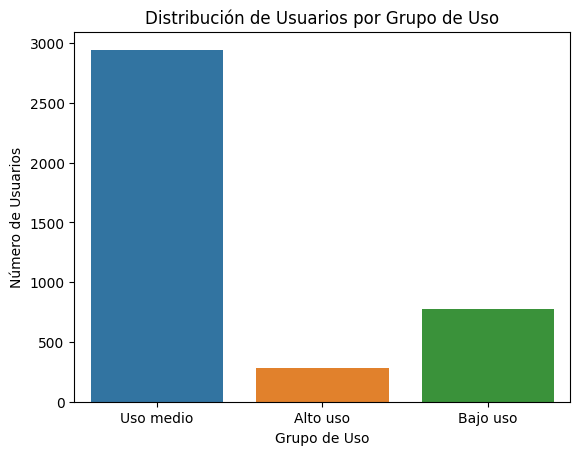

Uso medio    2943
Bajo uso      778
Alto uso      278
Name: grupo_uso, dtype: int64


In [188]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Número de Usuarios')
plt.show()
print(user_profile['grupo_uso'].value_counts())

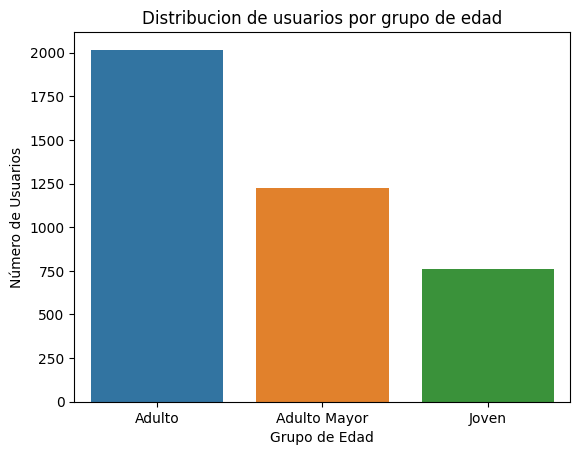

Adulto          2017
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


In [189]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribucion de usuarios por grupo de edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Número de Usuarios')
plt.show()
print(user_profile['grupo_edad'].value_counts())


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Se identificaron dos columnas con sentinels: `age` y `city`. Para la columna `age`, se optó por reemplazar los valores faltantes con la mediana, mientras que para `city` se decidió imputarlos como NA. En ambos casos, los registros faltantes no superaban el 5% del total de los datos.

🔍 **Segmentos por Edad**
- Para la variable `edad`, se segmentó a los usuarios en tres grupos: jóvenes (hasta 30 años), adultos (entre 30 y 60 años) y adultos mayores (más de 60 años). El análisis muestra que el 50% de los usuarios pertenece al segmento adulto, y que en conjunto, los adultos y adultos mayores concentran más del 80% de la base total de usuarios.


📊 **Segmentos por Nivel de Uso**
- Para clasificar el uso de los usuarios, se definieron tres grupos: uso bajo (menos de 5 mensajes y 5 llamadas), uso medio (entre 6 y 10 mensajes y entre 6 y 10 llamadas) y uso alto (más de 10 mensajes y más de 10 llamadas). El análisis muestra que más de dos terceras partes de los usuarios presentan un uso medio, mientras que aproximadamente solo el 7% corresponde a usuarios de alto uso.


💡 **Recomendaciones**
- Dado que más del 80% de los usuarios se concentra en los segmentos adulto y adulto mayor, es clave enfocar la estrategia del negocio en este público, ajustando la propuesta de valor, comunicación y funcionalidades a sus necesidades. Al mismo tiempo, considerando que más de dos terceras partes de los usuarios presentan un uso medio, existe una oportunidad clara de incrementar el engagement mediante incentivos, beneficios adicionales o mejoras en la experiencia que impulsen su transición hacia un mayor nivel de uso.

Por otro lado, aunque los usuarios de alto uso representan solo alrededor del 7%, constituyen un segmento estratégico por su alto valor. En este sentido, es recomendable analizarlos en detalle para diseñar estrategias de retención y posibles acciones de upselling, maximizando así su contribución al negocio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`